 # HADES: Hydrothermal-Anaerobic Digestion Environmental Study 
## Brightway2 Parametric Model

**Author:** Kassem Ibrahim Al Houssaini

---

## Overview

Two-pathway Life Cycle Assessment (LCA) of **Hydrothermal Carbonization (HTC)** coupled with **Anaerobic Digestion (AD)**.

The system is modeled using:

- An **ML surrogate model** for the HTC reactor based on **Tippayawong et al.** (2024)
- **ADM1** for anaerobic digestion **(Batstone et al., 2002)**: **Py-ADM1** based on **Sadrimjad et al. (2021)** for traditional feedstocks (food wastes) and a **modified PW-ADM1** version to account for resistant and toxic fractions in hydrothermal process waters  

---

## Pathways

### Pathway A  
**HTC first (raw feedstock)** → AD on process water  

### Pathway B  
**AD first (raw feedstock)** → HTC on digestate  

---

⚠️ **Prerequisite:**  
Ensure that **Brightway2** and **Ecoinvent** are installed and properly configured before running this notebook.

To run the streamlit app: conda activate your environment then 
streamlit run app.py


In [1]:
# %% ============================================================
# CELL 1 — IMPORTS 
# ============================================================
import sys
import importlib.util
import bw2data as bd
from brightway2 import LCA
 
 
def load_module(name, filepath):
    spec = importlib.util.spec_from_file_location(name, filepath)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module
 
 
# Loads ADM1.py + plot_adm1_batch.py internally by path
sb = load_module("system_builder", "ADM1/system_builder.py")
 
SystemContext = sb.SystemContext
build_system = sb.build_system
spinup_ss_state = sb.spinup_ss_state
get_or_create = sb.get_or_create
 
# Re-exported for convenience if you still use these names elsewhere
translate_pw_to_adm1 = sb.translate_pw_to_adm1
translate_feedstock_to_adm1 = sb.translate_feedstock_to_adm1
extract_digestate_composition = sb.extract_digestate_composition
run_adm1 = sb.run_adm1
plot_adm1_results = sb.plot_adm1_results
 
print("✅ Imports done. system_builder loaded from:", sb.__file__)

✅ Imports done. system_builder loaded from: C:\Users\khous\PhD_Kassem\HTC\ADM1/system_builder.py


In [9]:
# %% ============================================================
# CELL 2 — MASTER CONTROL PANEL
# All user-facing parameters in one place.
# Change values here; downstream cells read from these variables.
# ============================================================

# ── PATHWAY ─────────────────────────────────────────────────────
PATHWAY = "B"          # "A" = HTC → AD on PW  |  "B" = AD → HTC on digestate

# ── FEEDSTOCK ───────────────────────────────────────────────────
# Moisture content (wet basis, %)
WC_feed       = 85

# Ultimate analysis (dry basis, %) — must sum to 100 with Ash
C_feed   = 38.25
H_feed   = 5.47
N_feed   = 3.66
S_feed   = 0.5
Ash_feed = 9.1
O_feed   = 100 - C_feed - H_feed - N_feed - S_feed - Ash_feed  # = 35.0

# Proximate analysis (dry basis, wt%)
V_feed  = 82.6 # voltaile matter
Fc_feed = 8.3 # fixed carbon

# Functional unit — wet feedstock mass at gate (kg) or (kg/day) if continuous, for now keep it fixed at 1000
m_feedstock   = 1000.0

# ── HTC PROCESS ─────────────────────────────────────────────────
T_HTC         = 180    # reactor temperature (°C)
RT_HTC        = 60   # residence time (min)

# HTC slurry moisture target (wet basis, fraction)
# Reactor is diluted to this moisture before HTC if feedstock is drier
# Default: 0.80 (80% moisture = 20% dry matter)
target_moisture_HTC = 0.85

# Hydrochar moisture targets
MC_char            = 0.85   # moisture of wet hydrochar leaving HTC reactor (kg/kg wet)
target_MC_char_dry = 0.10   # moisture after drying step (kg/kg wet)

# ── AD PROCESS ──────────────────────────────────────────────────
adm1_mode     = "continuous"   # "continuous" (CSTR) or "batch" (BMP)
adm1_HRT_days = 30             # HRT in days — only used in continuous mode
adm1_t_sim    = None #22           # simulation length (d); None = auto (5 × HRT)
t_spinup      = 400            # spin-up duration (d); 400 is safe

# AD feed dilution target (kg solids / kg slurry, i.e. TS fraction)
# Feedstock/PW is diluted to this before entering the CSTR
# Default: 0.08 (8% total solids)
TS_target     = 0.08
COD_conc_target = 10  # kgCOD/m³ — max influent COD before PW dilution (Pathway A only)
ISR_batch     = 2 # inoculum-to-substrate ratio (gVSS/gCOD) # VDI 4630: ≥ 2  |  Holliger et al.: 2-4

# AD operating temperature (°C) — passed to ADM1 kinetics
# 37°C = mesophilic  |  55°C = thermophilic
T_AD          = 37.0

# ── DERIVED PARAMETER DICTS (do not edit below this line) ───────
default_params = {
    "WC":       WC_feed,
    "C_feed":   C_feed,
    "H_feed":   H_feed,
    "N_feed":   N_feed,
    "O_feed":   O_feed,
    "S_feed":   S_feed,
    "Ash_feed": Ash_feed,
    "VM_feed":   V_feed,
    "FC_feed":  Fc_feed,
}

htc_params = {
    "T":  T_HTC,
    "RT": RT_HTC,
}

ml_params = {**default_params, **htc_params}

# ── VALIDATION ──────────────────────────────────────────────────
_elem_sum = C_feed + H_feed + N_feed + O_feed + S_feed + Ash_feed
assert abs(_elem_sum - 100.0) < 0.5, \
    f"❌ Ultimate analysis sums to {_elem_sum:.1f}% — must be 100%"

assert 0.0 < target_moisture_HTC < 1.0, \
    "❌ target_moisture_HTC must be between 0 and 1"

assert 0.0 < TS_target < 1.0, \
    "❌ TS_target must be between 0 and 1"

assert adm1_mode in ("batch", "continuous"), \
    "❌ adm1_mode must be 'batch' or 'continuous'"

if adm1_mode == "continuous":
    assert adm1_HRT_days > 0, "❌ adm1_HRT_days must be > 0 in continuous mode"

if adm1_mode == "continuous":
    flow_unit = "kg/day"
else:
    flow_unit = "kg"

print("=" * 50)
print(f"  PATHWAY         : {PATHWAY}")
print(f"  Feedstock       : {m_feedstock:.0f} {flow_unit} wet  |  WC={WC_feed}%")
print(f"  Composition     : C={C_feed} H={H_feed} O={O_feed} N={N_feed} S={S_feed} Ash={Ash_feed} FC = {Fc_feed} VM = {V_feed} (dry %)")
print(f"  HTC             : T={T_HTC}°C  RT={RT_HTC} min  moisture target={target_moisture_HTC*100:.0f}%")
if adm1_mode == "continuous":
    print(f"  AD mode         : continuous")
    print(f"    HRT           : {adm1_HRT_days} d")
    print(f"    t_sim         : {adm1_t_sim} d  |  t_spinup={t_spinup} d")
    print(f"    T_AD          : {T_AD}°C")
    if PATHWAY == "A":
        print(f"    COD_target    : {COD_conc_target} kgCOD/m³  (PW dilution limit)")
    else:
        print(f"    TS_target     : {TS_target*100:.0f}%  (digestate dilution)")
else:
    print(f"  AD mode         : batch (BMP)")
    print(f"    t_sim         : {adm1_t_sim} d")
    print(f"    ISR           : {ISR_batch} gVSS/gCOD  (Holliger et al. ≥2)")
    print(f"    T_AD          : {T_AD}°C")
    if PATHWAY == "A":
        print(f"    COD_target    : {COD_conc_target} kgCOD/m³  (PW dilution limit)")
    else:
        print(f"    TS_target     : {TS_target*100:.0f}%  (digestate dilution)")

print("=" * 50)

  PATHWAY         : B
  Feedstock       : 1000 kg/day wet  |  WC=85%
  Composition     : C=38.25 H=5.47 O=43.02 N=3.66 S=0.5 Ash=9.1 FC = 8.3 VM = 82.6 (dry %)
  HTC             : T=180°C  RT=60 min  moisture target=85%
  AD mode         : continuous
    HRT           : 30 d
    t_sim         : None d  |  t_spinup=400 d
    T_AD          : 37.0°C
    TS_target     : 8%  (digestate dilution)


In [10]:
# %% ============================================================
# CELL 3 — BRIGHTWAY PROJECT, BACKGROUND PROCESSES & BIOSPHERE FLOWS
# Set REGION to your location. Examples:
#   Canadian province : "Quebec", "Ontario", "British Columbia"
#   Other country     : "France", "Germany", "United States", "China"
#   Direct ei code    : "CA-QC", "FR", "DE", "US", "CN"
#   Manual override   : "custom"
# ============================================================

# ── USER SETTING ──────────────────────────────────────────────
REGION = "quebec"

# ── LOCATION RESOLVER ─────────────────────────────────────────
PROVINCE_MAP = {
    "quebec":               "CA-QC",
    "ontario":              "CA-ON",
    "british columbia":     "CA-BC",
    "alberta":              "CA-AB",
    "manitoba":             "CA-MB",
    "saskatchewan":         "CA-SK",
    "nova scotia":          "CA-NS",
    "new brunswick":        "CA-NB",
    "newfoundland":         "CA-NL",
    "prince edward island": "CA-PE",
    "northwest territories":"CA-NT",
    "yukon":                "CA-YT",
    "nunavut":              "CA-NU",
}

COUNTRY_MAP = {
    "france":          "FR",
    "germany":         "DE",
    "united states":   "US",
    "usa":             "US",
    "china":           "CN",
    "united kingdom":  "GB",
    "uk":              "GB",
    "australia":       "AU",
    "brazil":          "BR",
    "india":           "IN",
    "japan":           "JP",
    "italy":           "IT",
    "spain":           "ES",
    "netherlands":     "NL",
    "sweden":          "SE",
    "norway":          "NO",
    "denmark":         "DK",
    "switzerland":     "CH",
    "belgium":         "BE",
    "austria":         "AT",
    "finland":         "FI",
    "portugal":        "PT",
    "poland":          "PL",
    "canada":          "CA",
    "mexico":          "MX",
    "south korea":     "KR",
    "new zealand":     "NZ",
    "south africa":    "ZA",
}

def resolve_location(region_str):
    """
    Resolve a region string to an ordered list of ecoinvent location codes.
    Priority: exact province/country code → country fallback → RoW → GLO
    """
    key = region_str.lower().strip()

    # Canadian province
    if key in PROVINCE_MAP:
        prov_code = PROVINCE_MAP[key]
        return [prov_code, "CA", "RoW", "GLO"]

    # Known country name
    if key in COUNTRY_MAP:
        country_code = COUNTRY_MAP[key]
        return [country_code, "RoW", "GLO"]

    # Direct ecoinvent code (e.g. "CA-QC", "FR", "DE")
    # Detect if it looks like a sub-national code (contains "-")
    if "-" in region_str:
        # Sub-national: fallback to parent country then RoW
        parent = region_str.split("-")[0]
        return [region_str, parent, "RoW", "GLO"]

    # Treat as a country code directly
    return [region_str, "RoW", "GLO"]


# ── PROJECT SETUP ─────────────────────────────────────────────
project_name   = "ei3.12"
ecoinvent_name = "ecoinvent-3.12-cutoff regionalized"
biosphere_name = "biosphere3"
bd.projects.set_current(project_name)
ei   = bd.Database(ecoinvent_name)
bios = bd.Database(biosphere_name)


# ══════════════════════════════════════════════════════════════
# CUSTOM MODE — set REGION = "custom" to specify each process
# manually. Useful for non-standard contexts or regions not
# covered by ecoinvent's regionalized datasets.
# ══════════════════════════════════════════════════════════════
if REGION.lower().strip() == "custom":
    print("🔧 CUSTOM MODE — fill in each process below then rerun")

    elec             = ei.search("market for electricity, medium voltage")[0]
    ad_elec          = elec
    drying_heat      = elec
    coal_heat        = ei.search("heat production, at hard coal industrial furnace 1-10MW")[0]
    ad_heat          = ei.search("heat production, natural gas")[0]
    ng_heat_market   = ei.search("market for heat, district or industrial, natural gas")[0]
    biomethane_heat_ref = ei.search("heat production, biomethane, at boiler condensing modulating")[0]
    tap_water        = ei.search("market for tap water")[0]
    wastewater_treat = ei.search("treatment of wastewater, average")[0]
    psa_ref          = ei.search("biogas purification to biomethane by pressure swing adsorption")[0]

    print("\n✅ Custom processes set. Verify locations:")
    for label, act in [
        ("elec", elec), ("ad_heat", ad_heat), ("coal_heat", coal_heat),
        ("ng_heat_market", ng_heat_market), ("tap_water", tap_water),
        ("wastewater_treat", wastewater_treat), ("psa_ref", psa_ref),
        ("biomethane_heat_ref", biomethane_heat_ref),
    ]:
        print(f"  {label:25s} → '{act['name'][:55]}'  [{act.get('location','?')}]")

else:
    # ══════════════════════════════════════════════════════════
    # AUTOMATIC MODE — resolves best available location
    # ══════════════════════════════════════════════════════════
    LOCATION_PRIORITY = resolve_location(REGION)
    print(f"🌍 Region: '{REGION}'  |  Location priority: {LOCATION_PRIORITY}")

    def find_process(query, priority=None, name_filter=None, fallback_any=True):
        if priority is None:
            priority = LOCATION_PRIORITY

        # First try: location-targeted search (include loc code in query)
        for loc in priority:
            targeted = ei.search(f"{query} {loc}", limit=100)
            if name_filter:
                targeted = [r for r in targeted
                            if name_filter.lower() in r["name"].lower()]
            for r in targeted:
                if r.get("location", "") == loc:
                    return r

        # Second try: broad search, scan all results
        results = ei.search(query, limit=200)
        if name_filter:
            results = [r for r in results
                       if name_filter.lower() in r["name"].lower()]
        for loc in priority:
            for r in results:
                if r.get("location", "") == loc:
                    return r

        # Final fallback
        if fallback_any and results:
            print(f"  ⚠️  No priority location found for '{query}' "
                  f"— using [{results[0].get('location','?')}] as fallback")
            return results[0]

        raise ValueError(f"No process found for query: '{query}'")

    # ── TECHNOSPHERE PROCESSES ─────────────────────────────────
    elec = find_process(
        "market for electricity, medium voltage",
        name_filter="market for electricity, medium voltage")
    ad_elec     = elec
    drying_heat = elec

    coal_heat = find_process(
        "heat production, at hard coal industrial furnace 1-10MW",
        name_filter="hard coal industrial furnace")

    ad_heat = find_process(
        "heat production, natural gas",
        name_filter="heat production, natural gas")

    ng_heat_market = find_process(
        "market for heat, district or industrial, natural gas",
        name_filter="market for heat, district or industrial, natural gas")

    biomethane_heat_ref = find_process(
        "heat production, biomethane, at boiler condensing modulating",
        priority=["RoW", "GLO"] + LOCATION_PRIORITY,
        name_filter="biomethane")

    tap_water = find_process(
        "market for tap water",
        name_filter="market for tap water")

    wastewater_treat = find_process(
        "treatment of wastewater, average",
        name_filter="treatment of wastewater, average")

    psa_ref = find_process(
        "biogas purification to biomethane by pressure swing adsorption",
        priority=["RoW", "GLO"] + LOCATION_PRIORITY)

    # ── SUMMARY ────────────────────────────────────────────────
    print(f"\n✅ Brightway project: '{project_name}'")
    print(f"✅ Region: '{REGION}'  →  resolved as {LOCATION_PRIORITY}")
    print()
    for label, act in [
        ("elec",              elec),
        ("ad_heat",           ad_heat),
        ("coal_heat",         coal_heat),
        ("ng_heat_market",    ng_heat_market),
        ("tap_water",         tap_water),
        ("wastewater_treat",  wastewater_treat),
        ("psa_ref",           psa_ref),
        ("biomethane_heat_ref", biomethane_heat_ref),
    ]:
        loc  = act.get("location", "?")
        flag = "✅" if loc == LOCATION_PRIORITY[0] else f"⚠️  (best available: {loc})"
        print(f"  {label:25s} → '{act['name'][:55]}'  [{loc}]  {flag}")

# ── BIOSPHERE FLOWS (always automatic — no regional variation) ─
co2_air       = [a for a in bios if "Carbon dioxide, non-fossil"  in a["name"]
                 and "air" in a["categories"]][0]
co_air        = [a for a in bios if "Carbon monoxide, non-fossil" in a["name"]
                 and "air" in a["categories"]][0]
ch4_air       = [a for a in bios if "Methane, non-fossil"         in a["name"]
                 and "air" in a["categories"]][0]
nh3_air       = [a for a in bios if "Ammonia"                     in a["name"]
                 and "air" in a["categories"]][0]
co2_nonfossil = [a for a in bios if a["name"] == "Carbon dioxide, non-fossil"
                 and "air" in a["categories"]][0]
co_nonfossil  = [a for a in bios if a["name"] == "Carbon monoxide, non-fossil"
                 and "air" in a["categories"]][0]
ch4_nonfossil = [a for a in bios if a["name"] == "Methane, non-fossil"
                 and "air" in a["categories"]][0]

print("\n✅ Biosphere flows resolved.")

🌍 Region: 'quebec'  |  Location priority: ['CA-QC', 'CA', 'RoW', 'GLO']

✅ Brightway project: 'ei3.12'
✅ Region: 'quebec'  →  resolved as ['CA-QC', 'CA', 'RoW', 'GLO']

  elec                      → 'market for electricity, medium voltage'  [CA-QC]  ✅
  ad_heat                   → 'heat production, natural gas, at industrial furnace >10'  [CA-QC]  ✅
  coal_heat                 → 'heat production, at hard coal industrial furnace 1-10MW'  [CA-QC]  ✅
  ng_heat_market            → 'market for heat, district or industrial, natural gas'  [CA-QC]  ✅
  tap_water                 → 'market for tap water'  [CA-QC]  ✅
  wastewater_treat          → 'treatment of wastewater, average, wastewater treatment'  [CA-QC]  ✅
  psa_ref                   → 'biogas purification to biomethane by pressure swing ads'  [RoW]  ⚠️  (best available: RoW)
  biomethane_heat_ref       → 'heat production, biomethane, at boiler condensing modul'  [RoW]  ⚠️  (best available: RoW)

✅ Biosphere flows resolved.


In [11]:
# %% ============================================================
# CELL 4 — FOREGROUND ACTIVITIES
# ============================================================
FOREGROUND_DB = f"Pathway{PATHWAY}"
 
if FOREGROUND_DB not in bd.databases:
    bd.Database(FOREGROUND_DB).register()
db = bd.Database(FOREGROUND_DB)
 
htc_reactor      = get_or_create(db, "htc_reactor",          "HTC reactor",                                            "unit")
drying           = get_or_create(db, "hydrochar_drying",      "Hydrochar drying",                                       "unit")
heat_prod        = get_or_create(db, "heat_prod_hydrochar",   "Heat production from hydrochar",                         "megajoule")
sub_heat_coal    = get_or_create(db, "substitute_heat_coal",  "Substitution of heat produced by hard coal combustion",  "megajoule", location="QC-CA")
ad_process       = get_or_create(db, "anaerobic_digestion",
                                 "Anaerobic digestion of HTC process water (ADM1)" if PATHWAY == "A"
                                 else "Anaerobic digestion of raw feedstock (ADM1)",               "unit")
dewatering       = get_or_create(db, "digestate dewatering", "Digestate Dewatering", "unit", location="CA-QC")
biogas_upgrading = get_or_create(db, "biogas_upgrading",      "Biogas upgrading (Pressure Swing Adsorption)",           "unit")
heat_biomethane  = get_or_create(db, "heat_biomethane",       "Heat production from biomethane",                        "megajoule")
heat_naturalgas  = get_or_create(db, "heat_naturalgas",       "Substitution of heat produced by Natural Gas Combustion","megajoule")
waste_treatment  = get_or_create(db, "waste_treatment_1kg",   "Waste treatment of organic waste (HTC system)",          "kilogram")
 
print("✅ All foreground activities declared.")

✅ All foreground activities declared.


In [12]:
# %% ============================================================
# NEW CELL 5 — BUILD THE SYSTEM CONTEXT
# One object that replaces every "global X" build_system used to
# rely on. Rebuild this cell any time you change providers, location,
# or Cell-2 parameters.
# ============================================================
ctx = SystemContext(
    ei=ei, bios=bios, FOREGROUND_DB=FOREGROUND_DB,
 
    elec=elec, ad_elec=ad_elec, ad_heat=ad_heat, drying_heat=drying_heat,
    coal_heat=coal_heat, ng_heat_market=ng_heat_market,
    biomethane_heat_ref=biomethane_heat_ref, tap_water=tap_water,
    wastewater_treat=wastewater_treat, psa_ref=psa_ref,
 
    co2_air=co2_air, co_air=co_air,
 
    htc_reactor=htc_reactor, drying=drying, heat_prod=heat_prod,
    sub_heat_coal=sub_heat_coal, ad_process=ad_process, dewatering=dewatering,
    biogas_upgrading=biogas_upgrading, heat_biomethane=heat_biomethane,
    heat_naturalgas=heat_naturalgas, waste_treatment=waste_treatment,
 
    PATHWAY=PATHWAY, m_feedstock=m_feedstock,
    default_params=default_params, ml_params=ml_params,
    T_HTC=T_HTC, RT_HTC=RT_HTC, target_moisture_HTC=target_moisture_HTC,
    MC_char=MC_char, target_MC_char_dry=target_MC_char_dry,
    COD_conc_target=COD_conc_target, ISR_batch=ISR_batch,
 
    location_country="Canada",
    location_province=REGION,
    location_code=LOCATION_PRIORITY[0] if REGION.lower().strip() != "custom" else "custom",
)
print("✅ SystemContext built.")

✅ SystemContext built.


In [13]:
# %% ============================================================
# CELL 6 — EXECUTION & VALIDATION
# ============================================================
# Point this at your ML model file. A full .py path (spaces allowed)
# is now the most robust option — no sys.path juggling needed.
ML_MODULE_PATH = "ML training scripts and models/ML2 model.py"
 
if adm1_mode == "continuous":
    ss_adapted = spinup_ss_state(
        ctx,
        pathway=PATHWAY,
        adm1_HRT_days=adm1_HRT_days,
        t_spinup=t_spinup,
        verbose=True,
        ml_module=ML_MODULE_PATH,
    )
else:
    ss_adapted = None
    print("📋 Batch mode: Resetting ss_adapted to None for clean inoculum.")
 
wt, ss_state, adm1_out, feed_inputs, inv = build_system(
    ctx,
    ml_module=ML_MODULE_PATH,
    adm1_mode=adm1_mode,
    adm1_HRT_days=adm1_HRT_days,
    adm1_t_sim_days=adm1_t_sim,
    adm1_ss_state=ss_adapted,
    ISR_batch=ISR_batch,
)
 
print(f"\n✅ Execution complete in {adm1_mode} mode.")


───────────────────────────────────────────────────────
SPIN-UP — Pathway B | HRT=30 d | t_sim=400 d
───────────────────────────────────────────────────────
🧹 Cleared all exchanges in 'PathwayB'
✅ Loaded ML module from: C:\Users\khous\PhD_Kassem\HTC\ML training scripts and models\ML2 model.py
🔀 Running PATHWAY B
⚙️  ADM1 mode: continuous | HRT=30 d

  PATHWAY B — Step 1: AD on raw feedstock
[compute_S_IN | feedstock] N_kg=5.4900  f_IN=0.000  S_IN=0.00010 kmolN/m³
[compute_S_IC] pH=8.00  T=35.0°C  p_CO2=0.0005 atm  S_IC=0.01000 kmolC/m³
[derive_fractions | feedstock]
  Elemental ratios: H/C=1.704  O/C=0.844  N/org=4.0%
  Fractions: S_su=0.140  S_aa=0.061  S_fa=0.042  S_I=0.020  X_ch=0.378  X_pr=0.165  X_li=0.114  X_I=0.080
[translate_feedstock] mode=continuous  COD_conc=78.766 kgCOD/m³
[translate_feedstock] OLR=2.63 kgCOD/m³/d  HRT=30.0 d
[Pathway B] Feedstock at gate:  1000.00 kg
[Pathway B] Dilution water → AD: 875.00 kg
[Pathway B] Total slurry to AD:  1875.00 kg
[run_adm1 continuou

ADM1 continuous:  38%|████████████████████████                                        | 150/400 [00:21<00:35,  6.99d/s]



[run_adm1] Converged at t=150.0 d (5×HRT)

[run_adm1 continuous] CH4 = 842.65369 kg  (1349.35882 m³)
[run_adm1 continuous] CO2 = 1801.15865 kg  (1048.81189 m³)
[run_adm1 continuous] NH3 = 1.21045 kg

=== SS DIAGNOSTIC ===
  X_ac      : 1.43797
  X_h2      : 0.73150
  X_pro     : 0.32573
  S_ac      : 0.04514
  S_pro     : 0.01212
  S_IN      : 0.07867
  S_nh3     : 0.00129
  pH        : 7.17609
  S_h2      : 0.00000

[ADM1 results B | continuous] CH4=842.6537 kg, CO2=1801.1587 kg, NH3=1.2105 kg  (time-integrated, no blank)

=== SS DIAGNOSTIC ===
X_ac  (acetoclastic methanogens) : 1.4380 kgCOD/m³
X_h2  (hydrogenotrophic methano) : 0.7315 kgCOD/m³
X_pro (propionate oxidisers)     : 0.3257 kgCOD/m³
S_ac  (acetate)                  : 0.0451 kgCOD/m³
S_pro (propionate)               : 0.0121 kgCOD/m³
S_IN  (inorg. nitrogen)          : 0.078674 kmolN/m³
S_nh3 (free ammonia)             : 0.001289 kmolN/m³
pH                               : 7.176
S_h2  (dissolved H2)             : 1.83e-07 k

ADM1 continuous:  25%|████████████████                                                | 150/600 [00:13<00:41, 10.75d/s]



[run_adm1] Converged at t=150.0 d (5×HRT)

[run_adm1 continuous] CH4 = 842.67483 kg  (1349.39268 m³)
[run_adm1 continuous] CO2 = 1801.19911 kg  (1048.83545 m³)
[run_adm1 continuous] NH3 = 1.21063 kg

=== SS DIAGNOSTIC ===
  X_ac      : 1.43842
  X_h2      : 0.73175
  X_pro     : 0.32584
  S_ac      : 0.04512
  S_pro     : 0.01211
  S_IN      : 0.07868
  S_nh3     : 0.00129
  pH        : 7.17612
  S_h2      : 0.00000

[ADM1 results B | continuous] CH4=842.6748 kg, CO2=1801.1991 kg, NH3=1.2106 kg  (time-integrated, no blank)

=== SS DIAGNOSTIC ===
X_ac  (acetoclastic methanogens) : 1.4384 kgCOD/m³
X_h2  (hydrogenotrophic methano) : 0.7317 kgCOD/m³
X_pro (propionate oxidisers)     : 0.3258 kgCOD/m³
S_ac  (acetate)                  : 0.0451 kgCOD/m³
S_pro (propionate)               : 0.0121 kgCOD/m³
S_IN  (inorg. nitrogen)          : 0.078680 kmolN/m³
S_nh3 (free ammonia)             : 0.001289 kmolN/m³
pH                               : 7.176
S_h2  (dissolved H2)             : 1.83e-07 k

---
**Extra features, not core of HADES**

---

---
**Quick numeric mass-based comparison between pathway A and pathway B: just make sure that your correct databases are called below.** 

---

In [14]:
# %% ============================================================
# CELL 7 — PATHWAY A vs B COMPARISON
# Reads from two separate foreground databases and compares
# LCA scores and mass flow metadata side by side.
# ============================================================

DB_A = "PathwayA"
DB_B = "PathwayB"

import brightway2 as bw
import pandas as pd

bd.projects.set_current(project_name)

def read_metadata(db_name):
    db  = bd.Database(db_name)
    wt  = [a for a in db if a.get("code") == "waste_treatment_1kg"][0]
    return {
        "PATHWAY":          wt.get("PATHWAY"),
        "adm1_mode":        wt.get("adm1_mode"),
        "HRT_days":         wt.get("adm1_HRT_days"),
        "CH4_AD (kg)":      wt.get("CH4_mass_AD"),
        "Biogas (m³)":      wt.get("biogas_m3"),
        "Biomethane (m³)":  wt.get("biomethane_m3"),
        "HC_wet (kg)":      wt.get("HC_wet_yield"),
        "HC_dry (kg)":      wt.get("HC_dry_yield"),
        "PW (kg)":          wt.get("PW_yield"),
        "MJ_hydrochar":     wt.get("MJ_hydrochar"),
        "NG_sub (MJ)":      wt.get("scaling_MJ_biomethane"),
        "added_water (kg)": wt.get("added_water_HTC"),
        "MB_HTC": wt.get("MB_HTC_A") if wt.get("MB_HTC_A") is not None else wt.get("MB_HTC_B"),
        "MB_AD":  wt.get("MB_AD_A")  if wt.get("MB_AD_A")  is not None else wt.get("MB_AD_B"),
    }

meta_A = read_metadata(DB_A)
meta_B = read_metadata(DB_B)

df_meta = pd.DataFrame([meta_A, meta_B], index=["Pathway A", "Pathway B"]).T
print("\n========== MASS FLOW COMPARISON ==========")
print(df_meta.to_string())


========== MASS FLOW COMPARISON ==========
                    Pathway A   Pathway B
PATHWAY                     A           B
adm1_mode          continuous  continuous
HRT_days                 30.0        30.0
CH4_AD (kg)          4.810168   28.089161
Biogas (m³)          12.05624   69.599903
Biomethane (m³)      6.516568   38.053752
HC_wet (kg)        672.586441  469.124688
HC_dry (kg)         112.09774   78.187448
PW (kg)            322.253559   277.48857
MJ_hydrochar      1622.153215  924.562635
NG_sub (MJ)          6.516568   38.053752
added_water (kg)          0.0         0.0
MB_HTC                    0.0         0.0
MB_AD                     0.0         0.0


---
**Quick numeric LCA comparison between pathway A and pathway B**

---

In [17]:
# %% ============================================================
# CELL 8 —LCA SCORE COMPARISON — run after both DBs are built
# ============================================================

DB_A = "PathwayA"
DB_B = "PathwayB"
method = ('IMPACT World+ Damage 2.2.1_regionalized for ecoinvent v3.12', 'Human health', 'Total human health')
results = {}
for db_name, label in [(DB_A, "Pathway A"), (DB_B, "Pathway B")]:
    db = bd.Database(db_name)
    wt = [a for a in db if a.get("code") == "waste_treatment_1kg"][0]
    fu = {wt: 1}
    lca = LCA(fu, method)
    lca.lci()
    lca.lcia()
    results[label] = lca.score

print("\n========== LCA SCORE COMPARISON ==========")
for label, score in results.items():
    print(f"  {label}: {score:.4f} DALY / functional unit")
print(f"  Difference (A - B): {results['Pathway A'] - results['Pathway B']:.4f}")


========== LCA SCORE COMPARISON ==========
  Pathway A: -0.0061 DALY / functional unit
  Pathway B: -0.0038 DALY / functional unit
  Difference (A - B): -0.0024


---
**Detailed mass-balance diagrams for pathways A and B: just make sure that your correct databases are called below.** 

---

Reading from database: 'PathwayA'


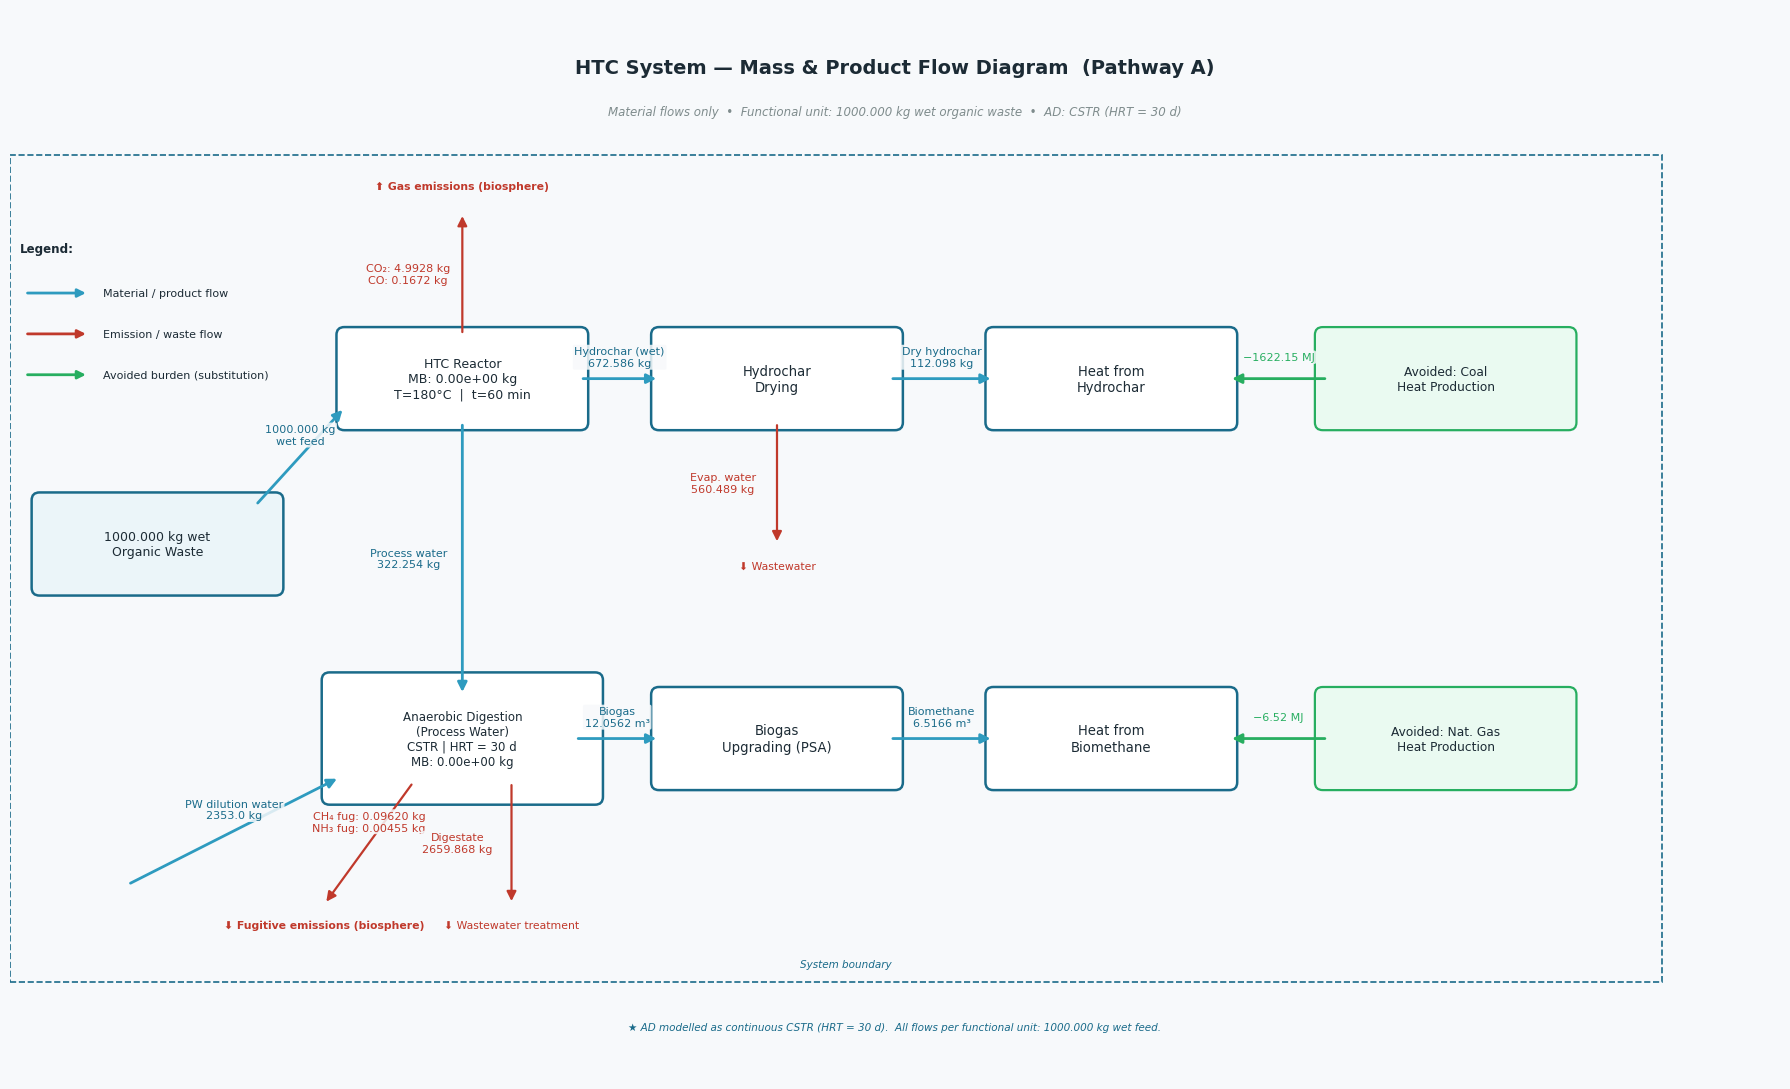

✅ Saved: HTC_mass_balance_pathwayA_PathwayA.png
Reading from database: 'PathwayB'


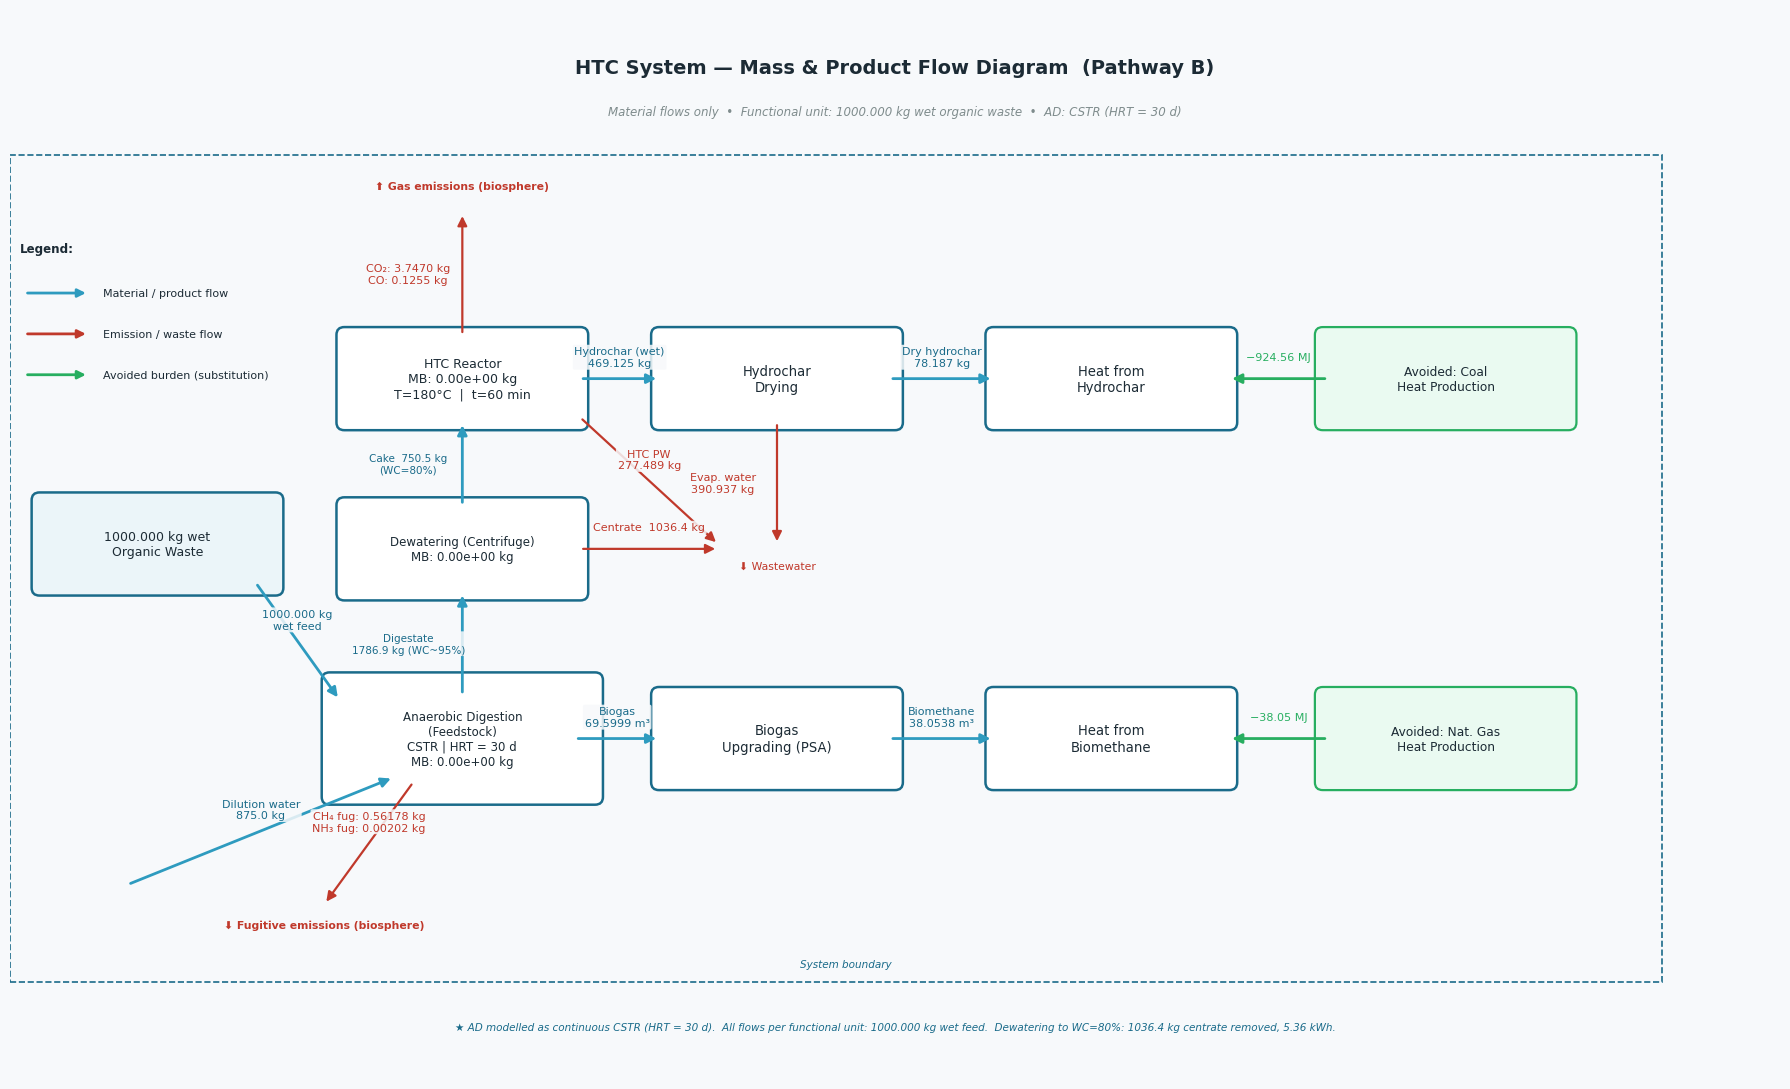

✅ Saved: HTC_mass_balance_pathwayB_PathwayB.png


In [20]:
# %% ============================================================
# CELL 9 — MASS BALANCE FLOW DIAGRAM
# Reads from FOREGROUND_DB (set in Cell 7).
# Pathway B: dewatering box inserted at x=4.6, y=5.5
#            between AD (y=3.5) and HTC (y=7.2) — same column.
# ============================================================
DB_A = "PathwayA"
DB_B = "PathwayB"

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

C_BOX    = '#FFFFFF'
C_BORDER = '#1A6B8A'
C_ARROW  = '#2E9BBF'
C_AVOIDED= '#27AE60'
C_EMIT   = '#C0392B'
C_TEXT   = '#1C2B35'
C_LABEL  = '#1A6B8A'
C_SUB    = '#7F8C8D'
C_DW     = '#8E44AD'

def _draw_box(ax, cx, cy, w, h, label, sublabel=None,
              fc=C_BOX, ec=C_BORDER, lw=1.8, fontsize=9.5):
    box = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                         boxstyle="round,pad=0.08",
                         facecolor=fc, edgecolor=ec, linewidth=lw, zorder=3)
    ax.add_patch(box)
    text = f"{label}\n{sublabel}" if sublabel else label
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fontsize,
            color=C_TEXT, zorder=4, fontfamily='DejaVu Sans')

def _arrow(ax, x1, y1, x2, y2, label=None, color=C_ARROW, lw=2.0,
           labelside='top', fontsize=8.0, label_color=C_LABEL):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=lw, mutation_scale=14), zorder=5)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        dy = 0.22 if labelside == 'top' else -0.22
        dx = 0.0
        if abs(x2-x1) < 0.1:
            dx = 0.55 if x1 > 9 else -0.55
            dy = 0
        ax.text(mx+dx, my+dy, label, ha='center', va='center',
                fontsize=fontsize, color=label_color, zorder=6,
                fontfamily='DejaVu Sans',
                bbox=dict(boxstyle='round,pad=0.15', fc='#F7F9FB', ec='none', alpha=0.85))

def _emit(ax, x1, y1, x2, y2, label=None):
    _arrow(ax, x1, y1, x2, y2, label=label, color=C_EMIT, lw=1.6, label_color=C_EMIT)

def _avoided(ax, x1, y1, x2, y2, label=None):
    _arrow(ax, x1, y1, x2, y2, label=label, color=C_AVOIDED, lw=2.0, label_color=C_AVOIDED)

def _load_diagram_data(db_name=None):
    db_name = db_name or FOREGROUND_DB
    bd.projects.set_current(project_name)
    if db_name not in bd.databases:
        raise ValueError(f"Database '{db_name}' not found.")
    vdb = bd.Database(db_name)
    print(f"Reading from database: '{db_name}'")

    def get(code):
        r = [a for a in vdb if a.get("code") == code]
        return r[0] if r else None

    wt = get("waste_treatment_1kg")
    ad = get("anaerobic_digestion")
    if wt is None:
        raise ValueError(f"'waste_treatment_1kg' not found in '{db_name}'")

    _pathway      = wt.get("PATHWAY",                "?")
    adm1_mode     = wt.get("adm1_mode",              "batch")
    HRT_days      = float(wt.get("adm1_HRT_days",    0.0))
    MJ_hc         = float(wt.get("MJ_hydrochar",     0.0))
    m_feed_eff    = float(wt.get("m_feedstock_effective", 0.0))
    HC_wet        = float(wt.get("HC_wet_yield",     0.0))
    HC_dry        = float(wt.get("HC_dry_yield",     0.0))
    PW_kg         = float(wt.get("PW_yield",         0.0))
    CO2_yield     = float(wt.get("CO2_yield_HTC",    0.0))
    CO_yield      = float(wt.get("CO_yield_HTC",     0.0))
    CH4_mass      = float(wt.get("CH4_mass_AD",      0.0))
    CO2_mass_AD   = float(wt.get("CO2_mass_AD",      0.0))
    biogas_m3     = float(wt.get("biogas_m3",        0.0))
    biomethane_m3 = float(wt.get("biomethane_m3",    0.0))
    scaling_MJ    = float(wt.get("scaling_MJ_biomethane", 0.0))
    added_water   = float(wt.get("added_water_HTC",  0.0))
    m_feedstock   = float(wt.get("m_feedstock",      1.0))
    MB_HTC_A      = wt.get("MB_HTC_A", None)
    MB_AD_A       = wt.get("MB_AD_A",  None)
    MB_HTC_B      = wt.get("MB_HTC_B", None)
    MB_AD_B       = wt.get("MB_AD_B",  None)
    MB_DW_B       = wt.get("MB_DW_B",  None)
    m_cake        = float(wt.get("m_cake_dewater_kg",     0.0))
    m_centrate    = float(wt.get("m_centrate_dewater_kg", 0.0))
    E_centrifuge  = float(wt.get("E_centrifuge_kWh",      0.0))
    dilution_water_AD = float(wt.get("dilution_water_AD_kg", 0.0))
    dilution_water_PW = float(wt.get("dilution_water_PW_m3", 0.0)) * 1000.0

    CH4_fug = NH3_fug = 0.0
    if ad is not None:
        for exc in ad.exchanges():
            if exc['type'] == 'biosphere':
                name = exc.input['name'].lower()
                if 'methane' in name:   CH4_fug = exc['amount']
                elif 'ammonia' in name: NH3_fug = exc['amount']

    evap_kg = HC_wet - HC_dry
    dig_kg  = max(0.0, PW_kg + dilution_water_PW - CH4_mass - CO2_mass_AD) if _pathway == "A" else PW_kg
    ad_mode_label = (f"CSTR  |  HRT = {HRT_days:.0f} d"
                     if adm1_mode == "continuous" and HRT_days > 0 else "Batch (BMP)")

    return dict(
        pathway=_pathway, adm1_mode=adm1_mode, HRT_days=HRT_days,
        ad_mode_label=ad_mode_label, m_feedstock=m_feedstock,
        MJ_hc=MJ_hc, scaling_MJ=scaling_MJ,
        CO2_yield=CO2_yield, CO_yield=CO_yield,
        CH4_fug=CH4_fug, NH3_fug=NH3_fug,
        HC_wet=HC_wet, HC_dry=HC_dry, evap_kg=evap_kg,
        PW_kg=PW_kg, dig_kg=dig_kg, m_feed_eff=m_feed_eff,
        CH4_mass=CH4_mass, CO2_mass_AD=CO2_mass_AD,
        biomethane_m3=biomethane_m3, biogas_m3=biogas_m3,
        added_water=added_water,
        MB_HTC_A=MB_HTC_A, MB_AD_A=MB_AD_A,
        MB_HTC_B=MB_HTC_B, MB_AD_B=MB_AD_B, MB_DW_B=MB_DW_B,
        m_cake=m_cake, m_centrate=m_centrate, E_centrifuge=E_centrifuge, dilution_water_AD=dilution_water_AD, dilution_water_PW=dilution_water_PW,
    )


def generate_mass_balance_diagram(db_name=None):
    db_name = db_name or FOREGROUND_DB
    d = _load_diagram_data(db_name)
    p = d['pathway']

    fig, ax = plt.subplots(figsize=(18, 11))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 11)
    ax.axis('off')
    fig.patch.set_facecolor('#F7F9FB')
    ax.set_facecolor('#F7F9FB')

    BW, BH = 2.4, 0.90

    # ── Title ─────────────────────────────────────────────────────────────
    ad_subtitle = (f"AD: CSTR (HRT = {d['HRT_days']:.0f} d)"
                   if d['adm1_mode'] == 'continuous' else "AD: Batch (BMP)")
    ax.text(9, 10.4,
            f"HTC System — Mass & Product Flow Diagram  (Pathway {p})",
            ha='center', va='center', fontsize=14, fontweight='bold',
            color=C_TEXT, fontfamily='DejaVu Sans')
    ax.text(9, 9.95,
            f"Material flows only  •  "
            f"Functional unit: {d['m_feedstock']:.3f} kg wet organic waste  •  {ad_subtitle}",
            ha='center', va='center', fontsize=8.5, color=C_SUB, fontstyle='italic')

    # =========================================================
    # BOXES — identical positions to original for both pathways
    # =========================================================
    _draw_box(ax, 1.5, 5.5, BW, BH,
              f"{d['m_feedstock']:.3f} kg wet\nOrganic Waste",
              fc='#EBF5F9', ec=C_BORDER, fontsize=9)

    mb_htc = d['MB_HTC_A'] if p == "A" else d['MB_HTC_B']
    _draw_box(ax, 4.6, 7.2, BW, BH,
              label=f"HTC Reactor\nMB: {mb_htc:.2e} kg",
              sublabel=f"T={T_HTC}°C  |  t={RT_HTC} min", fontsize=9)

    _draw_box(ax, 7.8, 7.2, BW, BH, "Hydrochar\nDrying")

    mb_ad = d['MB_AD_A'] if p == "A" else d['MB_AD_B']
    ad_substrate = "Process Water" if p == "A" else "Feedstock"
    if d['adm1_mode'] == 'continuous':
        ad_box_label = (f"Anaerobic Digestion\n({ad_substrate})\n"
                        f"CSTR | HRT = {d['HRT_days']:.0f} d")
    else:
        ad_box_label = f"Anaerobic Digestion\n({ad_substrate})\nBatch (BMP)"
    _draw_box(ax, 4.6, 3.5, BW+0.3, BH+0.3,
              label=f"{ad_box_label}\nMB: {mb_ad:.2e} kg", fontsize=8.5)

    _draw_box(ax, 7.8,  3.5, BW, BH, "Biogas\nUpgrading (PSA)")
    _draw_box(ax, 11.2, 3.5, BW, BH, "Heat from\nBiomethane")
    _draw_box(ax, 11.2, 7.2, BW, BH, "Heat from\nHydrochar")

    avk = dict(fc='#EAFAF1', ec=C_AVOIDED, lw=1.6, fontsize=8.8)
    _draw_box(ax, 14.6, 7.2, BW+0.1, BH, "Avoided: Coal\nHeat Production",    **avk)
    _draw_box(ax, 14.6, 3.5, BW+0.1, BH, "Avoided: Nat. Gas\nHeat Production", **avk)

    # ── Pathway B: dewatering box at same x=4.6, between y=3.5 and y=7.2 ─
    if p == "B":
        mb_dw = d['MB_DW_B'] if d['MB_DW_B'] is not None else 0.0
        _draw_box(ax, 4.6, 5.45, BW, BH,
                  label=f"Dewatering (Centrifuge)\nMB: {mb_dw:.2e} kg",
                  fc=C_BOX, ec=C_BORDER, lw=1.8, fontsize=8.5)

    # =========================================================
    # ARROWS
    # =========================================================

    # ── Feedstock input ────────────────────────────────────────────────────
    if p == "A":
        _arrow(ax, 2.5, 5.9, 3.4, 6.9,
               label=f"{d['m_feedstock']:.3f} kg\nwet feed", fontsize=8)
    else:
            _arrow(ax, 2.5, 5.1, 3.35, 3.9,
                   label=f"{d['m_feedstock']:.3f} kg\nwet feed", fontsize=8)
            # Dilution water arrow into AD — mirrors Pathway A's added_water arrow for HTC
            if d.get("dilution_water_AD", 0) > 0:
                _arrow(ax, 1.2, 2.0, 3.9, 3.1,
                       label=f"Dilution water\n{d['dilution_water_AD']:.1f} kg", fontsize=8)

    # ── Added water to HTC ────────────────────────────────────────────────
    if d["added_water"] > 0:
        _arrow(ax, 3.2, 8.8, 4.1, 7.8,
               label=f"Added water\n{d['added_water']:.3f} kg", fontsize=8)

    # ── HTC → Drying ──────────────────────────────────────────────────────
    _arrow(ax, 5.8, 7.2, 6.6, 7.2,
           label=f"Hydrochar (wet)\n{d['HC_wet']:.3f} kg", fontsize=8)

    # ── HTC gas emissions ─────────────────────────────────────────────────
    _emit(ax, 4.6, 7.65, 4.6, 8.9,
          label=f"CO₂: {d['CO2_yield']:.4f} kg\nCO: {d['CO_yield']:.4f} kg")
    ax.text(4.6, 9.15, "⬆ Gas emissions (biosphere)",
            ha='center', fontsize=7.8, color=C_EMIT, fontweight='bold')

    # ── Pathway-specific flows ─────────────────────────────────────────────
    biogas_label = f"Biogas\n{d['biogas_m3']:.4f} m³"

    if p == "A":
        _arrow(ax, 4.6, 6.75, 4.6, 3.95,
               label=f"Process water\n{d['PW_kg']:.3f} kg",
               labelside='top', fontsize=8)
        _arrow(ax, 5.75, 3.5, 6.6, 3.5, label=biogas_label, fontsize=8)
        
        # PW dilution water arrow into AD — only if dilution was applied
        if d.get("dilution_water_PW", 0) > 1.0:   # > 1 kg threshold avoids ghost arrows
            _arrow(ax, 1.2, 2.0, 3.35, 3.1,
                   label=f"PW dilution water\n{d['dilution_water_PW']:.1f} kg",
                   fontsize=8, color=C_ARROW)

    else:
        # AD (3.5) → Dewatering (5.45): up
        m_dig_total = d['m_cake'] + d['m_centrate']
        _arrow(ax, 4.6, 3.95, 4.6, 5.0,
               label=f"Digestate\n{m_dig_total:.1f} kg (WC~95%)",
               labelside='top', fontsize=7.5)

        # Dewatering (5.45) → HTC (7.2): up
        _arrow(ax, 4.6, 5.9, 4.6, 6.75,
               label=f"Cake  {d['m_cake']:.1f} kg\n(WC=80%)",
               labelside='top', fontsize=7.5)

        # Centrate → points right toward WWT (same area as HTC PW and evap water)
        _emit(ax, 5.8, 5.45, 7.2, 5.45,
              label=f"Centrate  {d['m_centrate']:.1f} kg")

        # HTC process water → WWT
        _emit(ax, 5.8, 6.8, 7.2, 5.5,
              label=f"HTC PW\n{d['PW_kg']:.3f} kg")

        # Biogas
        _arrow(ax, 5.75, 3.5, 6.6, 3.5, label=biogas_label, fontsize=8)

    # ── AD fugitive emissions ──────────────────────────────────────────────
    _emit(ax, 4.1, 3.05, 3.2, 1.8,
          label=f"CH₄ fug: {d['CH4_fug']:.5f} kg\nNH₃ fug: {d['NH3_fug']:.5f} kg")
    ax.text(3.2, 1.55, "⬇ Fugitive emissions (biosphere)",
            ha='center', fontsize=7.8, color=C_EMIT, fontweight='bold')

    # ── Digestate → WWT (Pathway A only) ──────────────────────────────────
    if p == "A":
        _emit(ax, 5.1, 3.05, 5.1, 1.8,
              label=f"Digestate\n{d['dig_kg']:.3f} kg")
        ax.text(5.1, 1.55, "⬇ Wastewater treatment",
                ha='center', fontsize=7.8, color=C_EMIT)

    # ── PSA → biomethane ──────────────────────────────────────────────────
    _arrow(ax, 8.95, 3.5, 10.0, 3.5,
           label=f"Biomethane\n{d['biomethane_m3']:.4f} m³", fontsize=8)

    # ── Drying → dry hydrochar ────────────────────────────────────────────
    _arrow(ax, 8.95, 7.2, 10.0, 7.2,
           label=f"Dry hydrochar\n{d['HC_dry']:.3f} kg", fontsize=8)

    # ── Drying evaporated water ───────────────────────────────────────────
    _emit(ax, 7.8, 6.75, 7.8, 5.5,
          label=f"Evap. water\n{d['evap_kg']:.3f} kg")
    ax.text(7.8, 5.25, "⬇ Wastewater", ha='center', fontsize=7.8, color=C_EMIT)

    # ── Avoided burdens ───────────────────────────────────────────────────
    _avoided(ax, 13.4, 7.2, 12.4, 7.2, label=f"−{d['MJ_hc']:.2f} MJ")
    _avoided(ax, 13.4, 3.5, 12.4, 3.5, label=f"−{d['scaling_MJ']:.2f} MJ")

    # ── Legend ────────────────────────────────────────────────────────────
    leg_x, leg_y = 0.1, 8.5
    ax.text(leg_x, leg_y, "Legend:", fontsize=8.5, fontweight='bold', color=C_TEXT)
    legend_items = [
        (C_ARROW,   "Material / product flow"),
        (C_EMIT,    "Emission / waste flow"),
        (C_AVOIDED, "Avoided burden (substitution)"),
    ]
    for i, (col, lbl) in enumerate(legend_items):
        yy = leg_y - 0.42 * (i + 1)
        ax.annotate("", xy=(leg_x+0.7, yy), xytext=(leg_x+0.05, yy),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.0, mutation_scale=12))
        ax.text(leg_x+0.85, yy, lbl, va='center', fontsize=8, color=C_TEXT)

    # ── Footnote ──────────────────────────────────────────────────────────
    if d['adm1_mode'] == 'continuous':
        footnote = (
            f"★ AD modelled as continuous CSTR (HRT = {d['HRT_days']:.0f} d).  "
            f"All flows per functional unit: {d['m_feedstock']:.3f} kg wet feed."
        )
        if p == "B" and d['m_centrate'] > 0:
            footnote += (
                f"  Dewatering to WC=80%: {d['m_centrate']:.1f} kg centrate removed, "
                f"{d['E_centrifuge']:.2f} kWh."
            )
        ax.text(9, 0.5, footnote,
                ha='center', fontsize=7.5, color=C_BORDER, style='italic')

    # ── System boundary ───────────────────────────────────────────────────
    boundary = plt.Polygon(
        [(0, 1.0), (16.8, 1.0), (16.8, 9.5), (0, 9.5)],
        fill=False, edgecolor=C_BORDER, linewidth=1.2, linestyle='--', zorder=1
    )
    ax.add_patch(boundary)
    ax.text(8.5, 1.15, "System boundary",
            ha='center', fontsize=7.5, color=C_BORDER, style='italic')

    plt.tight_layout()
    fname = f"HTC_mass_balance_pathway{p}_{db_name}.png"
    plt.savefig(fname, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"✅ Saved: {fname}")


for db in [DB_A, DB_B]:
    if db in bd.databases:
        generate_mass_balance_diagram(db_name=db)
    else:
        print(f"⚠️ '{db}' not found — skipping.")